In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
df=pd.read_csv('/kaggle/input/churndataset/customer_churn.csv')

# Data Manipulation #

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
customer_5=df.loc[:,['Dependents']]

In [6]:
customer_5

,Dependents
0,No
1,No
2,No
3,No
4,No
...,...
7038,Yes
7039,Yes
7040,Yes
7041,No


In [7]:
customer_15=df['StreamingMovies']

In [8]:
customer_15

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040     No
7041     No
7042    Yes
Name: StreamingMovies, Length: 7043, dtype: object

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
senior_male_electric=df[(df['gender']== 'Male') & (df['PaymentMethod']== 'Electronic check') & (df['SeniorCitizen']==1)] 

In [11]:
senior_male_electric

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
78,0191-ZHSKZ,Male,1,No,No,30,Yes,No,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,74.75,2111.3,No
91,2424-WVHPL,Male,1,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,74.70,74.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6837,6229-LSCKB,Male,1,No,No,6,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,79.70,497.6,No
6894,1400-MMYXY,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,Yes
6914,7142-HVGBG,Male,1,Yes,No,43,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.00,4414.3,Yes
6967,8739-WWKDU,Male,1,No,No,25,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.50,2196.15,Yes


In [12]:
customer_total_tenure=df[(df['tenure']>70) & (df['MonthlyCharges']>100)]

In [13]:
customer_total_tenure.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
17,9959-WOFKT,Male,0,No,Yes,71,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),106.70,7382.25,No
59,5954-BDFSG,Female,0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),107.50,7853.7,No
94,9848-JQJTX,Male,0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),100.90,7459.05,No
106,6728-DKUCO,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,One year,Yes,Electronic check,104.15,7303.05,No
193,9680-NIAUV,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Credit card (automatic),109.70,8129.3,No


In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
two_mail_yes=df[(df['Contract']=='Two Year') & (df['PaymentMethod']=='Mailed check') & (df['Churn']=='Yes')]

In [16]:
two_mail_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [17]:
customer_333=df.sample(n=333)

In [18]:
customer_333.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
737,2521-NPUZR,Male,0,Yes,No,70,Yes,No,Fiber optic,Yes,...,Yes,Yes,No,Yes,Two year,No,Credit card (automatic),101.00,7085.5,No
4541,9058-CBREO,Female,1,No,No,1,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,50.55,50.55,Yes
4469,6893-ODYYE,Male,0,No,No,50,Yes,No,Fiber optic,Yes,...,Yes,Yes,No,No,One year,Yes,Credit card (automatic),90.10,4549.45,No
3782,8800-JOOCF,Female,0,No,Yes,12,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,84.05,966.55,No
1639,4690-LLKUA,Male,1,No,No,17,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,45.05,770.6,Yes


In [19]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# Visualization Begins Here #

In [20]:
counts=df['InternetService'].value_counts()

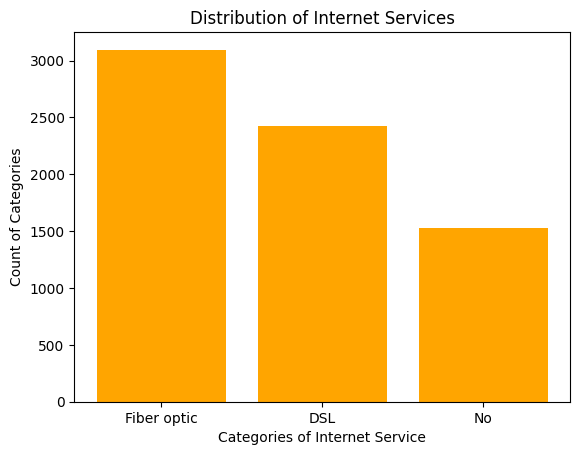

In [21]:
plt.bar(counts.index,counts.values,color='orange')
plt.xlabel("Categories of Internet Service")
plt.ylabel("Count of Categories")
plt.title("Distribution of Internet Services")
plt.show()

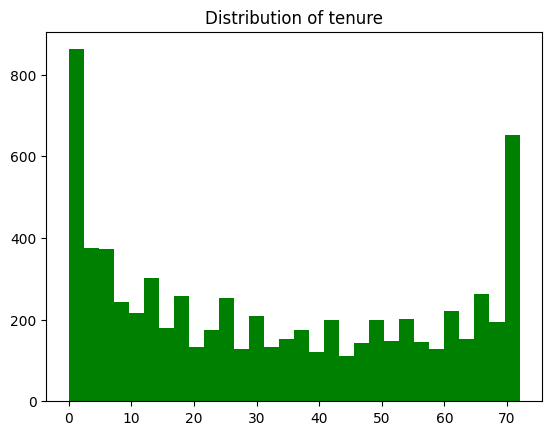

In [22]:
plt.hist(df['tenure'],color='green',bins=30)
plt.title('Distribution of tenure')
plt.show()

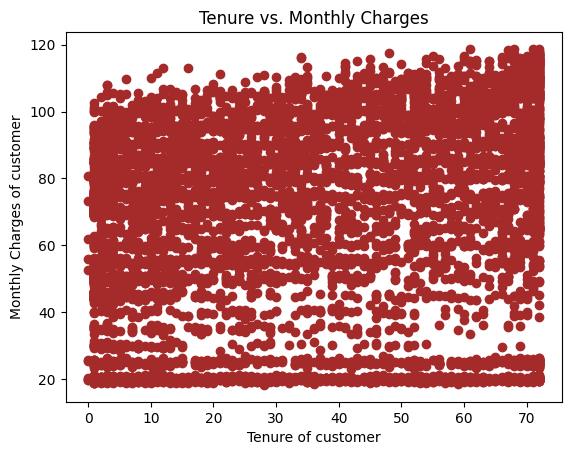

In [23]:
plt.scatter(x=df['tenure'],y=df['MonthlyCharges'],color='brown')
plt.xlabel('Tenure of customer')
plt.ylabel('Monthly Charges of customer')
plt.title('Tenure vs. Monthly Charges')
plt.show()

In [24]:
import seaborn as sns

<Axes: xlabel='Contract', ylabel='tenure'>

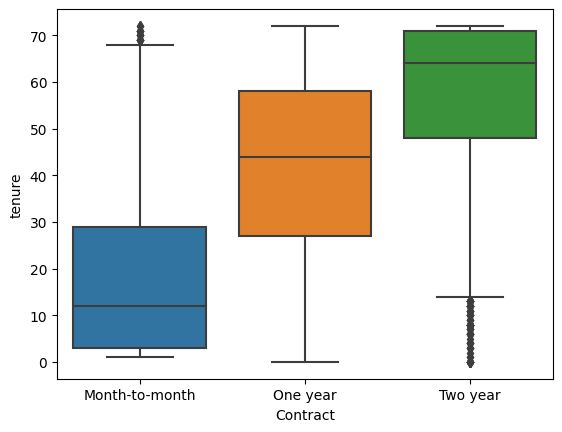

In [25]:
sns.boxplot(x=df['Contract'],y=df['tenure'])

# Linear Regression #

In [26]:
x=df.loc[:,["tenure"]].values
y=df.loc[:,["MonthlyCharges"]].values

In [27]:
x

array([[ 1],
       [34],
       [ 2],
       ...,
       [11],
       [ 4],
       [66]])

In [28]:
y

array([[ 29.85],
       [ 56.95],
       [ 53.85],
       ...,
       [ 29.6 ],
       [ 74.4 ],
       [105.65]])

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [30]:
model=LinearRegression()

In [31]:
model.fit(x_train,y_train)

LinearRegression()

In [32]:
y_pred=model.predict(x_test)

In [33]:
from sklearn.metrics import mean_squared_error

In [34]:
mse=mean_squared_error(y_pred,y_test)

In [35]:
rmse=np.sqrt(mse)

In [36]:
error=rmse

In [37]:
error

29.15550989402921

# Logistic Regression # 

In [38]:
x=df.loc[:,['MonthlyCharges']].values
y=df.loc[:,['Churn']].values

In [39]:
x

array([[ 29.85],
       [ 56.95],
       [ 53.85],
       ...,
       [ 29.6 ],
       [ 74.4 ],
       [105.65]])

In [40]:
y

array([['No'],
       ['No'],
       ['Yes'],
       ...,
       ['No'],
       ['Yes'],
       ['No']], dtype=object)

In [41]:
model=LogisticRegression()

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.35,random_state=1)

In [43]:
model.fit(x_train,y_train)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [44]:
y_pred=model.predict(x_test)

In [45]:
from sklearn.metrics import confusion_matrix


In [46]:
confusion_matrix(y_test,y_pred)

array([[1840,    0],
       [ 626,    0]])

In [47]:
from sklearn.metrics import accuracy_score

In [48]:
accuracy_score(y_test,y_pred)

0.7461476074614761

# Multiple Logistic Regression #

In [49]:
x=df.loc[:,['tenure','MonthlyCharges']]
y=df.loc[:,['Churn']]

In [50]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=1)

In [51]:
model=LogisticRegression()

In [52]:
model.fit(x_train,y_train)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [53]:
y_pred=model.predict(x_test)

In [54]:
from sklearn.metrics import confusion_matrix

In [55]:
confusion_matrix(y_test,y_pred)

array([[965,  96],
       [190, 158]])

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7970191625266146

#  Decision Tree #

In [57]:
x=df.loc[:,['tenure']]
y=df.loc[:,['Churn']]

In [58]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=1)

In [59]:
clf=DecisionTreeClassifier()

In [60]:
clf.fit(x_train,y_train)

DecisionTreeClassifier()

In [61]:
y_pred=clf.predict(x_test)

In [62]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [63]:
accuracy_score(y_test,y_pred)

0.7643718949609652

In [64]:
confusion_matrix(y_test,y_pred)

array([[983,  78],
       [254,  94]])

In [65]:
from sklearn import tree

[Text(0.3828125, 0.9666666666666667, 'x[0] <= 17.5\ngini = 0.394\nsamples = 5634\nvalue = [4113, 1521]'),
 Text(0.07834101382488479, 0.9, 'x[0] <= 2.5\ngini = 0.496\nsamples = 2122\nvalue = [1156, 966]'),
 Text(0.02457757296466974, 0.8333333333333334, 'x[0] <= 0.5\ngini = 0.482\nsamples = 687\nvalue = [278, 409]'),
 Text(0.01228878648233487, 0.7666666666666667, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.03686635944700461, 0.7666666666666667, 'x[0] <= 1.5\ngini = 0.479\nsamples = 679\nvalue = [270, 409]'),
 Text(0.02457757296466974, 0.7, 'gini = 0.464\nsamples = 485\nvalue = [177, 308]'),
 Text(0.04915514592933948, 0.7, 'gini = 0.499\nsamples = 194\nvalue = [93, 101]'),
 Text(0.13210445468509985, 0.8333333333333334, 'x[0] <= 5.5\ngini = 0.475\nsamples = 1435\nvalue = [878, 557]'),
 Text(0.08602150537634409, 0.7666666666666667, 'x[0] <= 3.5\ngini = 0.498\nsamples = 419\nvalue = [222, 197]'),
 Text(0.07373271889400922, 0.7, 'gini = 0.495\nsamples = 165\nvalue = [91, 74]'),
 Text(

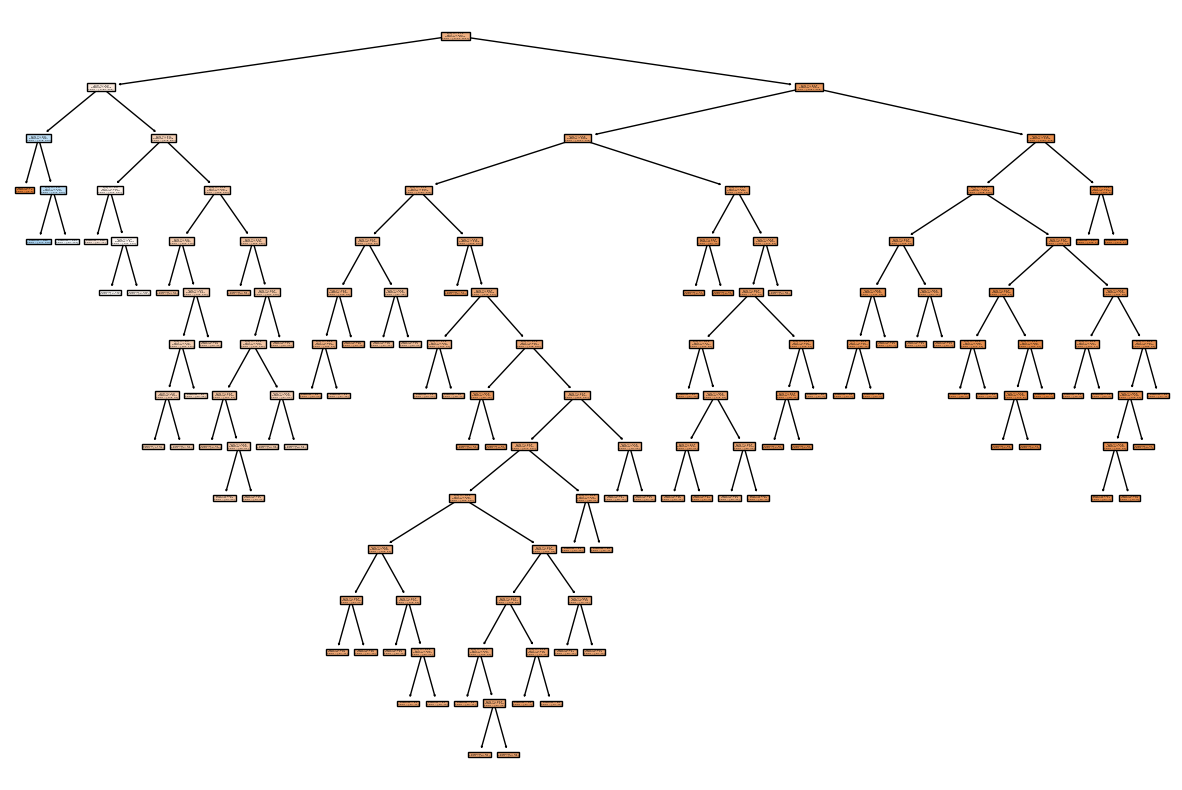

In [66]:
plt.figure(figsize=(15,10))
tree.plot_tree(clf,filled=True)

# Random Forest 

In [67]:
x=df.loc[:,['tenure','MonthlyCharges']]
y=df.loc[:,['Churn']]

In [68]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [69]:
rf=RandomForestClassifier()

In [70]:
rf.fit(x_train,y_train)

/tmp/ipykernel_18/1149647727.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(x_train,y_train)


RandomForestClassifier()

In [71]:
y_pred=rf.predict(x_test)

In [72]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [73]:
confusion_matrix(y_test,y_pred)

array([[1359,  226],
       [ 270,  258]])

In [74]:
accuracy_score(y_test,y_pred)

0.7652626597255088

## So this is the completion of my first project ## 